# PCA Manifolds in a Common Space

For each animal-FOV, **match cells across all sessions** using the global cell index, then:

1. Concatenate tuning curves from every run (common cells only)
2. Fit PCA on the concatenated set → shared PC axes
3. Project each run's tuning curves back into the common space
4. Colour-code ring manifolds by session/run

This reveals how the ring manifold drifts, rotates, or deforms across environments and recording days.

In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
import seaborn as sns

from remapping.dataset import (
    MiceDataset, Animals, GROUP_ORDER,
    EXPERIMENT_ORDER, SESSION_TYPE_MAP,
    EXPERIMENT_TYPE_ORDER, EXPERIMENT_TYPE_COLORS,
    COLORS_EXPERIMENTS,
)
from remapping.processing import smooth_tuning_curves_circularly
from remapping.plotting import BehaviorColors, PlotStyle, get_figures_path
from remapping.metrics import safe_corrcoef

mice = MiceDataset()
colors = BehaviorColors()
style = PlotStyle()
palette = mice.get_group_palette()

In [2]:
# --- Parameters ---

# Processing pipeline
ONLY_MOVING = True
BINS_COMPRESS = 3
BINS_SMOOTHING = 3
BINS_PHI = 360
TC_KERNEL = 20

# PCA
N_PLOT_PCS = 3

# Colourmap for angular position
PHI_CMAP = colors.angular_position

# Figure output
fig_path = get_figures_path("1.embeddings", "01_pca_manifolds_common_space")

## 1 — Collect tuning curves with matched cells across sessions

For each subject-FOV, load all sessions/runs, map local cell IDs to global IDs, find the intersection, and store tuning curves for the common cells.

In [3]:
fov_records = []  # one entry per subject-FOV that has ≥2 registered runs

for subject in Animals:
    info = mice.get_subject_info(subject)
    group = f"{info['genotype']}_{info['age']}"
    for fov in mice.get_available_fovs(subject):
        # Collect all runs with their global cell IDs
        runs_data = []  # list of dicts: session, run, cell_ids, tuning_curves, phi_bins
        for session in mice.get_available_sessions(subject, fov):
            for run in mice.get_available_runs(subject, fov, session):
                _, _, _, (cell_ids, registered), tc_raw, phi_bins = mice.load_firing_rates(
                    subject, fov, session, run,
                    only_moving=ONLY_MOVING,
                    bins_compress=BINS_COMPRESS,
                    bins_smoothing=BINS_SMOOTHING,
                    bins_phi=BINS_PHI,
                )
                if not registered:
                    continue
                tc = smooth_tuning_curves_circularly(tc_raw, kernel_size=TC_KERNEL)
                runs_data.append({
                    "session": session, "run": run,
                    "cell_ids": cell_ids,
                    "tc": tc,           # (360, N_local)
                    "phi_bins": phi_bins,
                })

        if len(runs_data) < 2:
            continue

        # Find common global cell IDs across ALL runs
        common_ids = set(runs_data[0]["cell_ids"])
        for rd in runs_data[1:]:
            common_ids &= set(rd["cell_ids"])
        common_ids = sorted(common_ids, key=int)

        if len(common_ids) < N_PLOT_PCS:
            continue

        # Subset each run's tuning curves to the common cells (in same order)
        run_entries = []
        for rd in runs_data:
            col_idx = [rd["cell_ids"].index(cid) for cid in common_ids]
            run_entries.append({
                "session": rd["session"],
                "run": rd["run"],
                "tc": rd["tc"][:, col_idx],      # (360, n_common)
                "phi_bins": rd["phi_bins"],
            })

        fov_records.append({
            "subject": subject,
            "fov": fov,
            "group": group,
            "n_common": len(common_ids),
            "n_runs": len(run_entries),
            "runs": run_entries,
        })

print(f"Collected {len(fov_records)} animal-FOVs with ≥2 registered runs")
print(f"Common cells per FOV: min={min(r['n_common'] for r in fov_records)}, "
      f"max={max(r['n_common'] for r in fov_records)}, "
      f"median={np.median([r['n_common'] for r in fov_records]):.0f}")

Collected 42 animal-FOVs with ≥2 registered runs
Common cells per FOV: min=3, max=265, median=66


## 2 — PCA in common space per animal-FOV

For each FOV: concatenate tuning curves from all runs → fit PCA → project each run separately → store projections and variance explained.

In [4]:
for rec in fov_records:
    # Concatenate tuning curves: (n_runs * 360, n_common)
    tc_concat = np.vstack([rd["tc"] for rd in rec["runs"]])
    pca = PCA(n_components=min(N_PLOT_PCS, rec["n_common"])).fit(tc_concat)

    rec["var_explained"] = pca.explained_variance_ratio_
    rec["cumvar_3"] = pca.explained_variance_ratio_[:3].sum()

    # Project each run individually
    for rd in rec["runs"]:
        rd["pca_proj"] = pca.transform(rd["tc"])  # (360, N_PLOT_PCS)

print(f"Median cumulative variance (3 PCs): "
      f"{np.median([r['cumvar_3'] for r in fov_records]):.1%}")

Median cumulative variance (3 PCs): 44.1%


## 3 — Gallery: rings in common PC space per animal-FOV

Each panel shows one FOV. All runs from that FOV are overlaid in the same PC1–PC2 space, colour-coded by session/run.

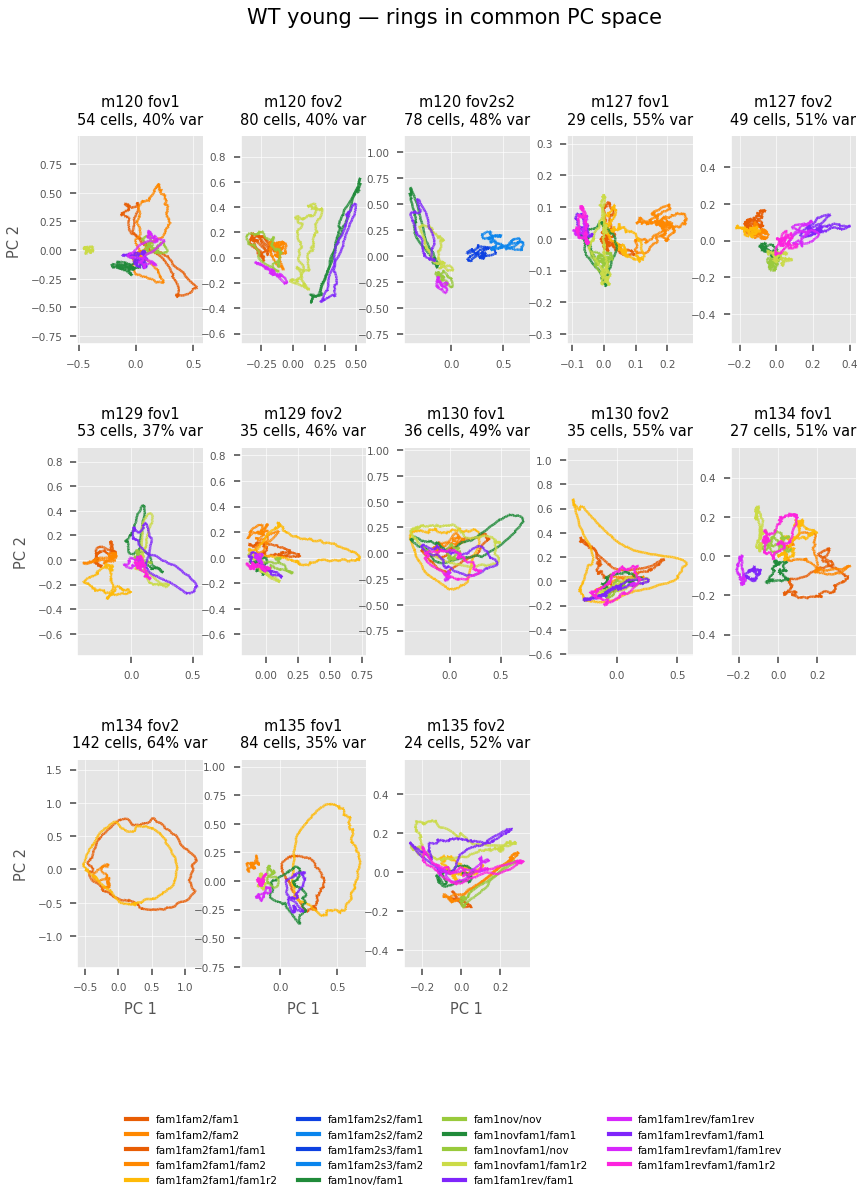

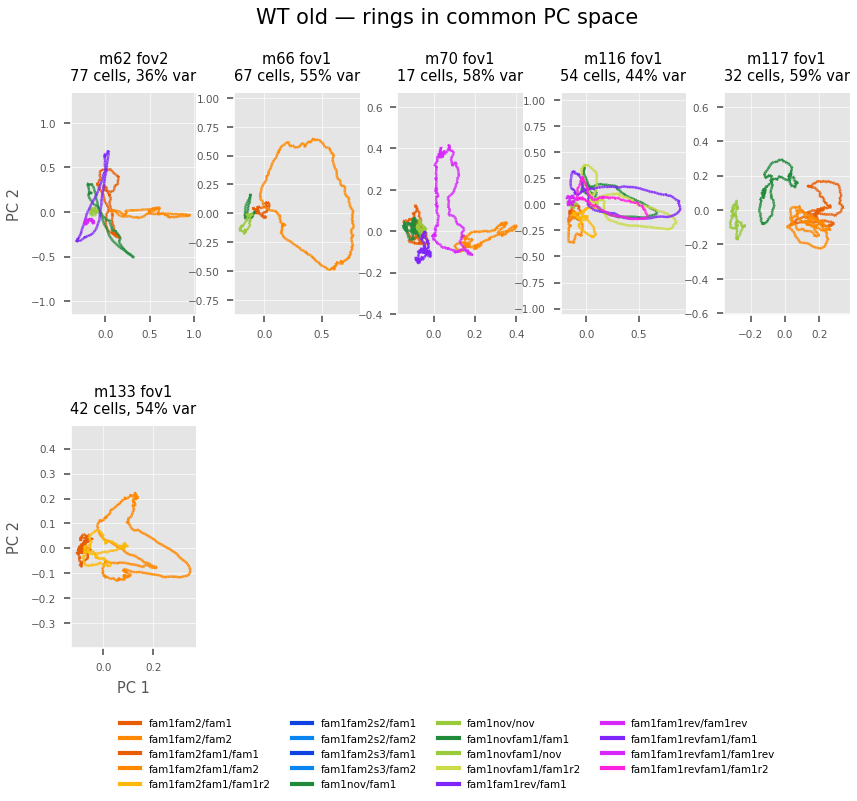

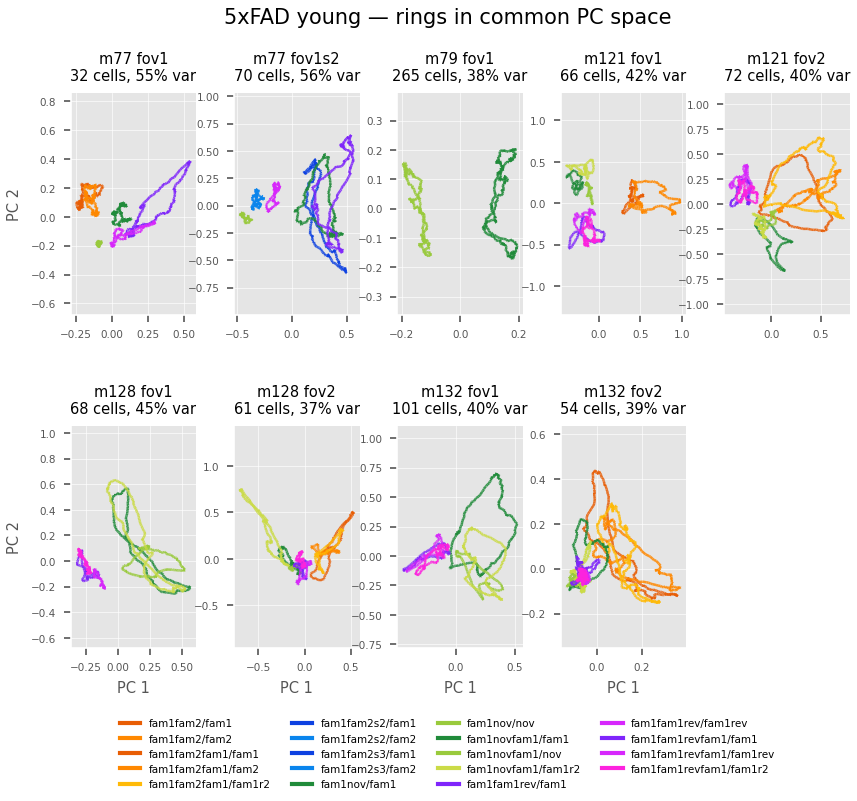

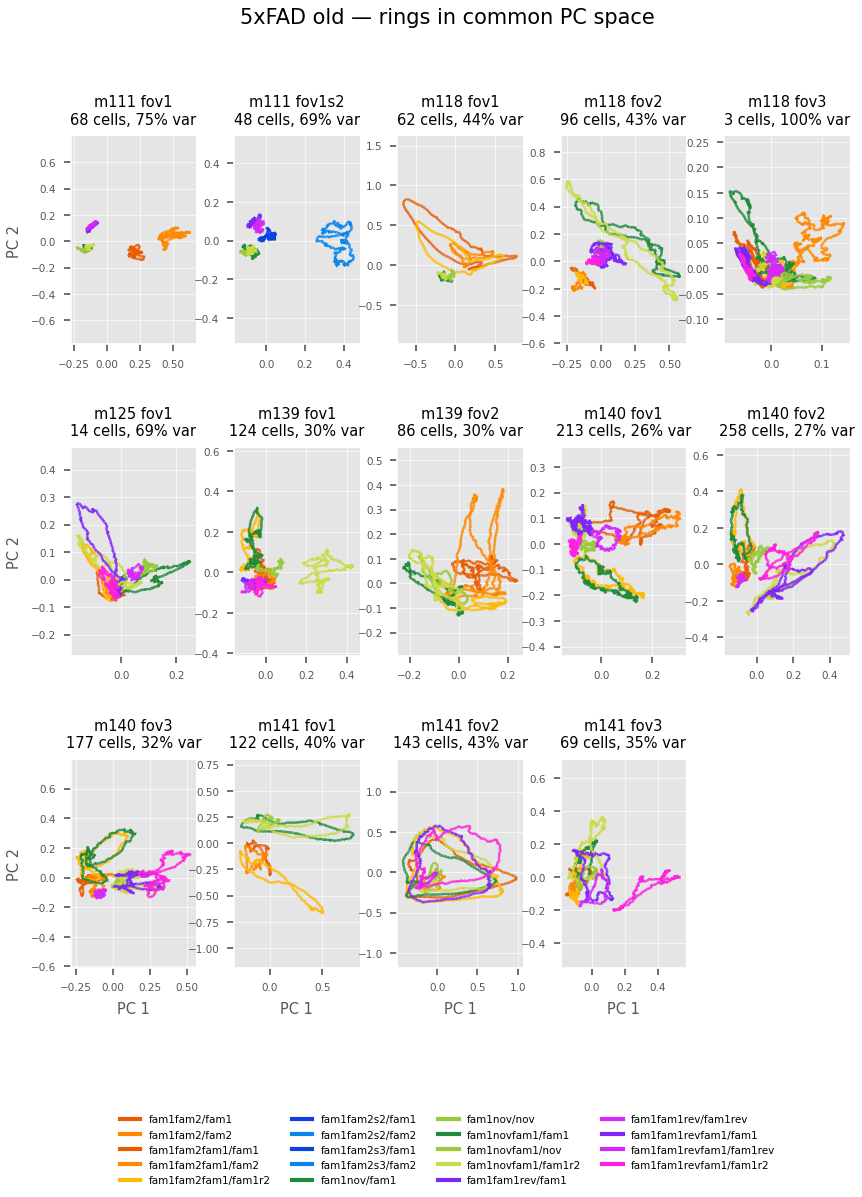

In [11]:
# Group FOV records by genotype×age group for organised gallery pages
from collections import defaultdict

fov_by_group = defaultdict(list)
for rec in fov_records:
    fov_by_group[rec["group"]].append(rec)

for group in GROUP_ORDER:
    recs = fov_by_group.get(group, [])
    if not recs:
        continue
    n = len(recs)
    ncols = min(n, 5)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(PlotStyle.FULL_WIDTH, 2.4 * nrows),
        squeeze=False,
    )
    fig.suptitle(f"{group.replace('_', ' ')} — rings in common PC space",
                 fontsize=10, y=1.0)

    for idx, rec in enumerate(recs):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]

        for rd in rec["runs"]:
            proj = rd["pca_proj"][:, :2]
            color = mice.get_experiment_color(rd["session"], rd["run"])
            # Close ring
            pts = np.vstack([proj, proj[:1]])
            segs = np.stack([pts[:-1], pts[1:]], axis=1)
            lc = LineCollection(segs, colors=[color] * len(segs), linewidths=1.2, alpha=0.85)
            ax.add_collection(lc)

        ax.set_aspect("equal", adjustable="datalim")
        ax.autoscale_view()
        ax.tick_params(labelsize=5)
        ax.set_title(
            f"{rec['subject'].value} fov{rec['fov']}\n"
            f"{rec['n_common']} cells, {rec['cumvar_3']:.0%} var",
            fontsize=7,
        )
        if col == 0:
            ax.set_ylabel("PC 2", fontsize=7)
        if row == nrows - 1:
            ax.set_xlabel("PC 1", fontsize=7)

    # Hide unused axes
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].set_visible(False)

    # Build legend from EXPERIMENT_ORDER
    seen = set()
    handles = []
    for sess, run in EXPERIMENT_ORDER:
        label = f"{sess}/{run}"
        if label in seen:
            continue
        seen.add(label)
        c = COLORS_EXPERIMENTS.get((sess, run), "#888888")
        handles.append(plt.Line2D([0], [0], color=c, lw=2, label=label))
    fig.legend(handles=handles, fontsize=5, ncol=4, loc="lower center",
               bbox_to_anchor=(0.5, -0.1), frameon=False)

    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    fig.savefig(fig_path / f"gallery_common_space_{group}.pdf", bbox_inches="tight")
    plt.show()

## 4 — Pairwise ring similarity across runs

For every pair of runs within each FOV, compute the **column-wise Pearson correlation** of their tuning curves in the common-cell space (averaged across cells). This measures how similar the angular firing profiles are between runs.

In [6]:
pair_records = []

for rec in fov_records:
    runs = rec["runs"]
    for i in range(len(runs)):
        for j in range(i + 1, len(runs)):
            tc_i, tc_j = runs[i]["tc"], runs[j]["tc"]  # (360, n_common)
            # Per-cell correlation, then average
            corrs = np.array([safe_corrcoef(tc_i[:, k], tc_j[:, k])
                              for k in range(tc_i.shape[1])])
            mean_corr = np.nanmean(corrs)

            # Classify the pair type
            run_i_label = runs[i]["run"]
            run_j_label = runs[j]["run"]
            same_session = runs[i]["session"] == runs[j]["session"]

            # Determine if both are fam1-type runs
            fam1_runs = {"fam1", "fam1r2"}
            both_fam1 = run_i_label in fam1_runs and run_j_label in fam1_runs

            if same_session:
                pair_type = "within-session"
            else:
                pair_type = "across-session"

            # Determine environment pair
            env_pair = f"{run_i_label} vs {run_j_label}"

            pair_records.append({
                "subject": rec["subject"].value,
                "fov": rec["fov"],
                "group": rec["group"],
                "session_i": runs[i]["session"],
                "run_i": run_i_label,
                "session_j": runs[j]["session"],
                "run_j": run_j_label,
                "pair_type": pair_type,
                "mean_corr": mean_corr,
                "same_run_type": run_i_label == run_j_label,
            })

df_pairs = pd.DataFrame(pair_records)
print(f"Total pairs: {len(df_pairs)}")
print(f"Within-session: {(df_pairs['pair_type'] == 'within-session').sum()}")
print(f"Across-session: {(df_pairs['pair_type'] == 'across-session').sum()}")
df_pairs.head()

Total pairs: 1079
Within-session: 283
Across-session: 796


,subject,fov,group,session_i,run_i,session_j,run_j,pair_type,mean_corr,same_run_type
0,m62,2,WT_old,fam1fam2,fam1,fam1fam2,fam2,within-session,0.037014,False
1,m62,2,WT_old,fam1fam2,fam1,fam1nov,fam1,across-session,0.155746,True
2,m62,2,WT_old,fam1fam2,fam1,fam1nov,nov,across-session,0.042820,False
3,m62,2,WT_old,fam1fam2,fam1,fam1fam1rev,fam1,across-session,0.083542,True
4,m62,2,WT_old,fam1fam2,fam1,fam1fam1rev,fam1rev,across-session,0.064949,False


### 4a — Within- vs across-session tuning curve similarity by group

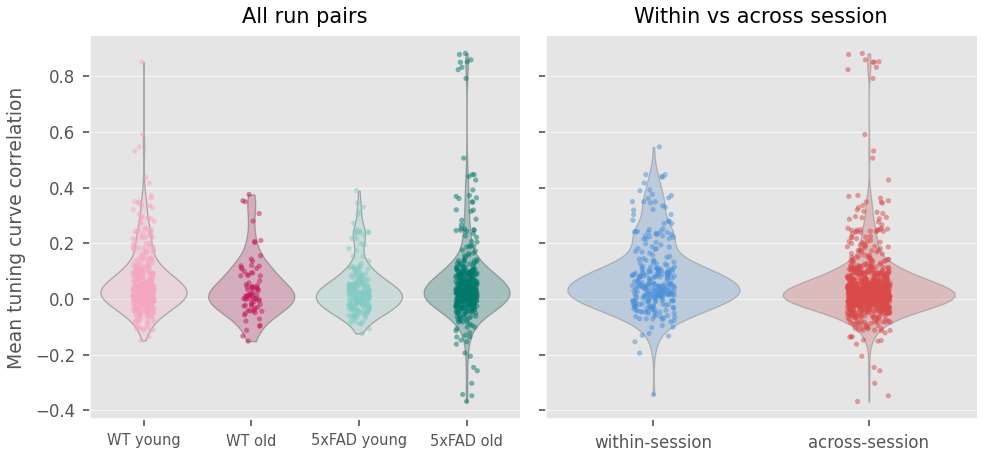

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.2), sharey=True)

# --- Left: by group ---
ax = axes[0]
sns.violinplot(
    data=df_pairs, x="group", y="mean_corr", hue="group",
    order=GROUP_ORDER, palette=palette,
    inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df_pairs, x="group", y="mean_corr", hue="group",
    order=GROUP_ORDER, palette=palette,
    size=2.5, alpha=0.5, jitter=True, ax=ax, legend=False,
)
ax.set_ylabel("Mean tuning curve correlation")
ax.set_xlabel("")
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace("_", " ") for g in GROUP_ORDER], fontsize=7)
ax.set_title("All run pairs")

# --- Right: within vs across session ---
ax = axes[1]
pair_order = ["within-session", "across-session"]
pair_palette = {"within-session": "#4a90d9", "across-session": "#d94a4a"}
sns.violinplot(
    data=df_pairs, x="pair_type", y="mean_corr", hue="pair_type",
    order=pair_order, palette=pair_palette,
    inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df_pairs, x="pair_type", y="mean_corr", hue="pair_type",
    order=pair_order, palette=pair_palette,
    size=2.5, alpha=0.5, jitter=True, ax=ax, legend=False,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("Within vs across session")

plt.tight_layout()
fig.savefig(fig_path / "pairwise_tc_correlation.pdf")
plt.show()

### 4b — Within-session similarity split by group and pair type

For within-session pairs only: does run-pair type (fam1 vs fam2, vs nov, vs reversed) matter?

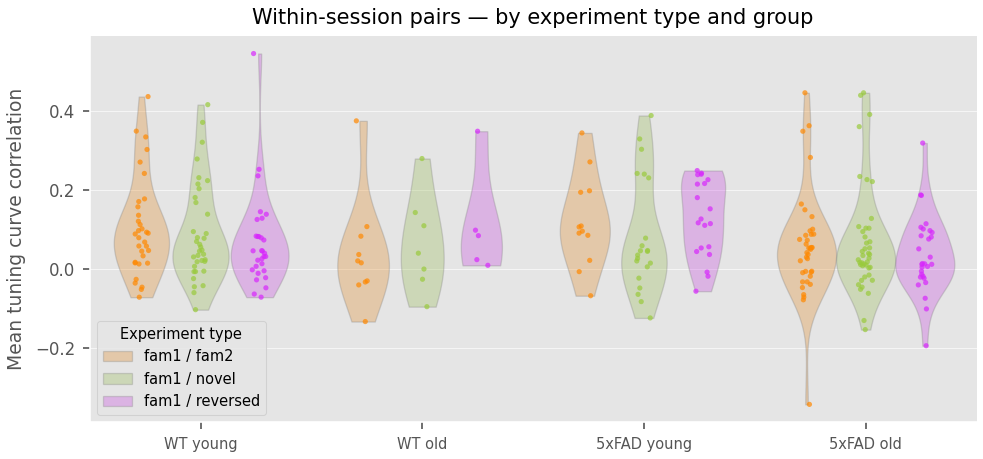

In [8]:
# For within-session pairs, label by experiment type
df_within = df_pairs[df_pairs["pair_type"] == "within-session"].copy()
df_within["exp_type"] = df_within["session_i"].map(SESSION_TYPE_MAP)
df_within = df_within.dropna(subset=["exp_type"])

# Build palette from actual data values to avoid any Unicode key issues
exp_order_data = sorted(df_within["exp_type"].unique(), key=lambda x: list(EXPERIMENT_TYPE_ORDER).index(x) if x in EXPERIMENT_TYPE_ORDER else 999)
exp_palette_data = {et: EXPERIMENT_TYPE_COLORS.get(et, "#888888") for et in exp_order_data}

fig, ax = plt.subplots(figsize=(PlotStyle.FULL_WIDTH, 3.2))

sns.violinplot(
    data=df_within, x="group", y="mean_corr", hue="exp_type",
    order=GROUP_ORDER, hue_order=exp_order_data,
    palette=exp_palette_data,
    inner=None, alpha=0.3, ax=ax, cut=0, dodge=True,
    linecolor="grey",
)
sns.stripplot(
    data=df_within, x="group", y="mean_corr", hue="exp_type",
    order=GROUP_ORDER, hue_order=exp_order_data,
    palette=exp_palette_data,
    size=2.5, alpha=0.7, jitter=True, ax=ax, dodge=True,
)

ax.set_ylabel("Mean tuning curve correlation")
ax.set_xlabel("")
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace("_", " ") for g in GROUP_ORDER], fontsize=7)
ax.set_title("Within-session pairs — by experiment type and group")

# De-duplicate legend
handles, labels = ax.get_legend_handles_labels()
n_unique = len(exp_order_data)
ax.legend(handles[:n_unique], labels[:n_unique], fontsize=7, title="Experiment type",
          title_fontsize=7, loc="lower left")

plt.tight_layout()
fig.savefig(fig_path / "within_session_corr_by_exptype.pdf")
plt.show()

## 5 — Variance explained in common PC space by group

How much variance do the first 3 common-space PCs capture? Compare across genotype × age.

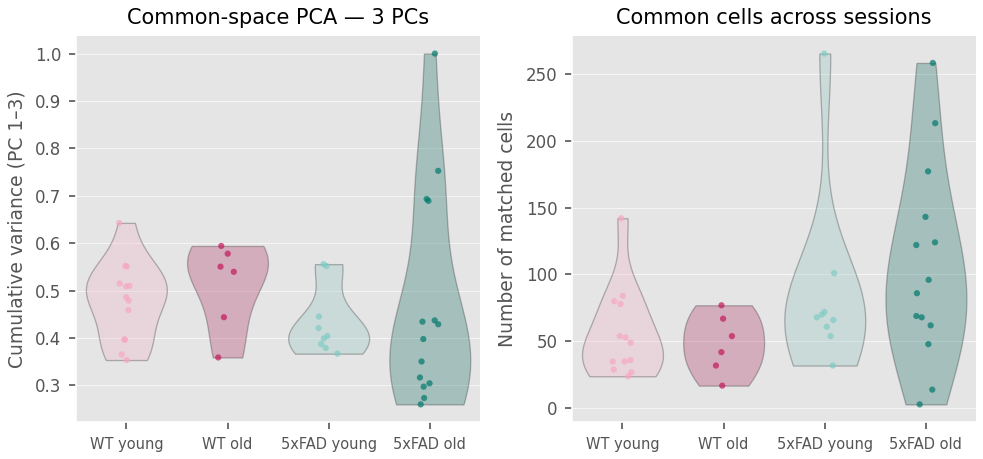

In [9]:
df_fov = pd.DataFrame([
    {"subject": r["subject"].value, "fov": r["fov"], "group": r["group"],
     "n_common": r["n_common"], "n_runs": r["n_runs"],
     "cumvar_3": r["cumvar_3"]}
    for r in fov_records
])

fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.2))

# Left: cumvar by group
ax = axes[0]
sns.violinplot(
    data=df_fov, x="group", y="cumvar_3", hue="group",
    order=GROUP_ORDER, palette=palette,
    inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df_fov, x="group", y="cumvar_3", hue="group",
    order=GROUP_ORDER, palette=palette,
    size=3, alpha=0.7, jitter=True, ax=ax, legend=False,
)
ax.set_ylabel("Cumulative variance (PC 1–3)")
ax.set_xlabel("")
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace("_", " ") for g in GROUP_ORDER], fontsize=7)
ax.set_title("Common-space PCA — 3 PCs")

# Right: n_common cells by group
ax = axes[1]
sns.violinplot(
    data=df_fov, x="group", y="n_common", hue="group",
    order=GROUP_ORDER, palette=palette,
    inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df_fov, x="group", y="n_common", hue="group",
    order=GROUP_ORDER, palette=palette,
    size=3, alpha=0.7, jitter=True, ax=ax, legend=False,
)
ax.set_ylabel("Number of matched cells")
ax.set_xlabel("")
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace("_", " ") for g in GROUP_ORDER], fontsize=7)
ax.set_title("Common cells across sessions")

plt.tight_layout()
fig.savefig(fig_path / "common_space_variance_and_cells.pdf")
plt.show()

## 6 — Similarity vs number of matched cells

Check whether correlation is confounded by the number of common cells (more cells → better estimation → higher correlation?).

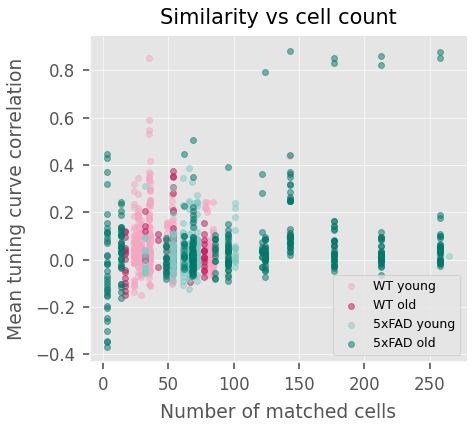

In [10]:
# Merge n_common into pair df
fov_ncells = {(r["subject"].value, r["fov"]): r["n_common"] for r in fov_records}
df_pairs["n_common"] = df_pairs.apply(
    lambda row: fov_ncells.get((row["subject"], row["fov"]), np.nan), axis=1
)

fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.0))
for group in GROUP_ORDER:
    mask = df_pairs["group"] == group
    ax.scatter(df_pairs.loc[mask, "n_common"], df_pairs.loc[mask, "mean_corr"],
               color=palette[group], s=8, alpha=0.5, label=group.replace("_", " "))
ax.set_xlabel("Number of matched cells")
ax.set_ylabel("Mean tuning curve correlation")
ax.set_title("Similarity vs cell count")
ax.legend(fontsize=6)
plt.tight_layout()
fig.savefig(fig_path / "corr_vs_ncells.pdf")
plt.show()